Pip install

In [ ]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 6.6 MB/s eta 0:00:00


Libaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import sklearn.metrics as met
from lazypredict.Supervised import LazyClassifier
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

Load Data

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.chdir('/content/drive/MyDrive/Apprenticeship')

In [ ]:
raw_df = pd.read_csv("f1_dataset_pit_speed.csv")

print ("Raw shape:", raw_df.shape)
display(raw_df.head())

Raw shape: (3161, 16)


,position,lap_time_ms,year,month,day,circuit_id,driver_number,driver_age,pit_next_lap,stint,race_progressed,nationality_id,compound_id,tyre_life,position_change,fast_stop
0,16,95463,2022,11,20,24,23,30,0,1,0.218182,19,NaN,NaN,-1,1
1,12,94033,2022,11,20,24,23,30,0,2,0.636364,19,NaN,NaN,-1,1
2,17,91974,2025,12,7,24,23,30,0,1,0.145455,19,1.0,8.0,-2,1
3,12,94282,2023,11,26,24,23,30,0,1,0.290909,19,2.0,17.0,-1,1
4,14,92201,2024,12,8,24,23,30,0,1,0.218182,19,2.0,12.0,0,1


In [ ]:
#raw_df = pd.read_csv("f1_dataset_pit_speed.csv")

#print ("Raw shape:", raw_df.shape)
#display(raw_df.head())

Basic EDA

In [ ]:
raw_df.describe()

,position,lap_time_ms,year,month,day,circuit_id,driver_number,driver_age,pit_next_lap,stint,race_progressed,nationality_id,compound_id,tyre_life,position_change,fast_stop
count,3161.000000,3.161000e+03,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,2822.000000,3161.000000,2951.000000,2951.000000,3161.000000,3161.000000
mean,9.795318,1.149950e+05,2023.526732,7.173996,16.043024,30.107561,28.488453,30.452072,0.040177,1.701677,0.446862,10.132869,2.281938,19.387326,-0.840873,0.507434
std,5.606861,1.639667e+05,1.115766,2.666975,9.620096,27.947495,21.281446,6.020350,0.196406,0.921213,0.243934,5.195976,0.870890,10.279654,1.848619,0.500024
min,1.000000,7.222800e+04,2022.000000,3.000000,1.000000,1.000000,2.000000,19.000000,0.000000,1.000000,0.012821,1.000000,1.000000,1.000000,-15.000000,0.000000
25%,5.000000,8.933400e+04,2023.000000,5.000000,7.000000,7.000000,14.000000,27.000000,0.000000,1.000000,0.250000,5.000000,2.000000,12.000000,-1.000000,0.000000
50%,10.000000,1.004200e+05,2024.000000,7.000000,18.000000,18.000000,23.000000,28.000000,0.000000,1.000000,0.432667,10.000000,2.000000,18.000000,0.000000,1.000000
75%,15.000000,1.129930e+05,2025.000000,10.000000,24.000000,69.000000,38.000000,33.000000,0.000000,2.000000,0.636364,15.000000,3.000000,25.000000,0.000000,1.000000
max,20.000000,2.588523e+06,2025.000000,12.000000,31.000000,80.000000,81.000000,45.000000,1.000000,7.000000,1.018182,19.000000,5.000000,72.000000,8.000000,1.000000


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161 entries, 0 to 3160
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   position         3161 non-null   int64  
 1   lap_time_ms      3161 non-null   int64  
 2   year             3161 non-null   int64  
 3   month            3161 non-null   int64  
 4   day              3161 non-null   int64  
 5   circuit_id       3161 non-null   int64  
 6   driver_number    3161 non-null   int64  
 7   driver_age       3161 non-null   int64  
 8   pit_next_lap     3161 non-null   int64  
 9   stint            3161 non-null   int64  
 10  race_progressed  2822 non-null   float64
 11  nationality_id   3161 non-null   int64  
 12  compound_id      2951 non-null   float64
 13  tyre_life        2951 non-null   float64
 14  position_change  3161 non-null   int64  
 15  fast_stop        3161 non-null   int64  
dtypes: float64(3), int64(13)
memory usage: 395.3 KB


In [ ]:
sum(raw_df.duplicated())

0

[Text(0.5, 1.0, 'Balanced variable')]

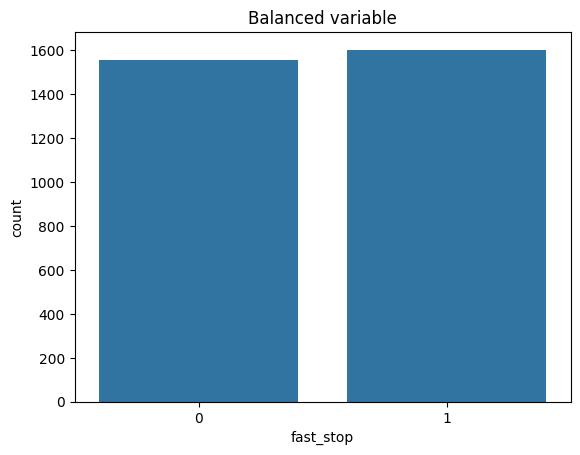

In [ ]:
g = sns.countplot(data=raw_df, x="fast_stop")
g.set(title='Balanced variable')

Clean df

In [ ]:
clean_df = raw_df.dropna()

In [ ]:
print ("Clean shape:", clean_df.shape)
display(clean_df.head())

Clean shape: (2612, 16)


,position,lap_time_ms,year,month,day,circuit_id,driver_number,driver_age,pit_next_lap,stint,race_progressed,nationality_id,compound_id,tyre_life,position_change,fast_stop
2,17,91974,2025,12,7,24,23,30,0,1,0.145455,19,1.0,8.0,-2,1
3,12,94282,2023,11,26,24,23,30,0,1,0.290909,19,2.0,17.0,-1,1
4,14,92201,2024,12,8,24,23,30,0,1,0.218182,19,2.0,12.0,0,1
5,13,92175,2023,11,26,24,23,30,0,2,0.781818,19,3.0,27.0,0,1
6,13,91616,2025,12,7,24,23,30,0,2,0.600000,19,3.0,25.0,1,1


Split into train and test set

In [ ]:
raw_df_train, raw_df_test = train_test_split(clean_df, test_size=0.2, random_state=42)
print ("Train shape:", raw_df_train.shape)
print ("Test shape:", raw_df_test.shape)

Train shape: (2089, 16)
Test shape: (523, 16)


In [ ]:
print(raw_df_train['fast_stop'].value_counts(normalize=True))
print(raw_df_test['fast_stop'].value_counts(normalize=True))

fast_stop
0    0.541407
1    0.458593
Name: proportion, dtype: float64
fast_stop
0    0.556405
1    0.443595
Name: proportion, dtype: float64


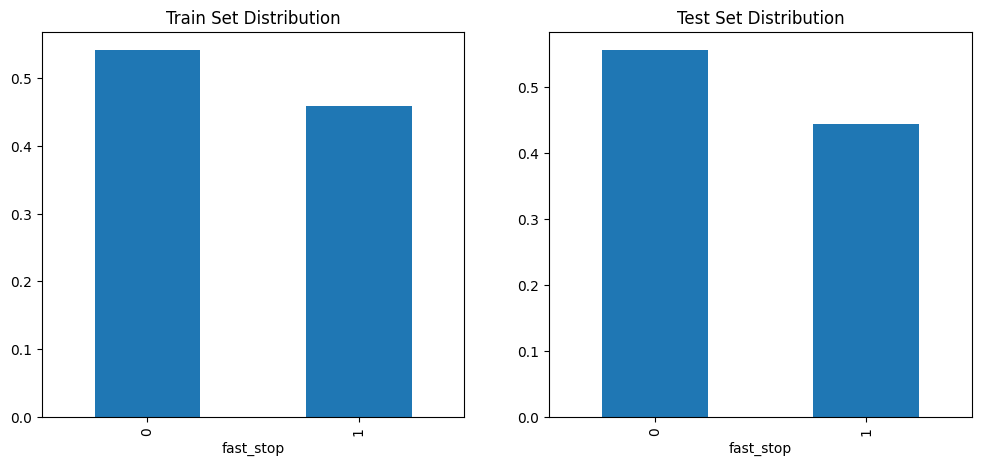

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
raw_df_train['fast_stop'].value_counts(normalize=True).plot(kind='bar', ax=axs[0])
axs[0].set_title("Train Set Distribution")

raw_df_test['fast_stop'].value_counts(normalize=True).plot(kind='bar', ax=axs[1])
axs[1].set_title("Test Set Distribution")

plt.show()

EDA on train set

In [ ]:
corr = raw_df_train.corr(numeric_only= True)
corr

,position,lap_time_ms,year,month,day,circuit_id,driver_number,driver_age,pit_next_lap,stint,race_progressed,nationality_id,compound_id,tyre_life,position_change,fast_stop
position,1.000000,0.172836,0.015252,-0.055162,0.050107,-0.056808,-0.141913,-0.029369,-0.010186,0.060074,-0.166464,-0.050813,0.012871,-0.222261,-0.293949,-0.109171
lap_time_ms,0.172836,1.000000,-0.098137,-0.130248,0.002870,-0.075900,-0.033709,0.024252,0.119841,-0.039578,-0.132848,0.002908,0.165178,-0.326018,0.021390,-0.106152
year,0.015252,-0.098137,1.000000,0.003920,0.052554,-0.047515,0.049765,-0.177930,0.096488,-0.022282,0.091129,0.004438,0.017066,0.108221,-0.042622,0.064395
month,-0.055162,-0.130248,0.003920,1.000000,-0.030207,0.309265,0.026543,-0.018597,0.051917,-0.045570,0.001467,-0.002539,-0.046076,0.034554,0.029336,-0.030940
day,0.050107,0.002870,0.052554,-0.030207,1.000000,0.065939,0.011143,-0.024331,-0.116126,-0.109698,-0.039566,0.014978,-0.046350,0.062436,-0.117317,0.156449
circuit_id,-0.056808,-0.075900,-0.047515,0.309265,0.065939,1.000000,0.043998,0.011080,-0.009164,-0.129015,-0.090264,0.001822,-0.076349,-0.057066,0.075274,0.297910
driver_number,-0.141913,-0.033709,0.049765,0.026543,0.011143,0.043998,1.000000,-0.011823,-0.020343,-0.033015,0.031724,-0.140722,0.006416,0.054893,-0.005998,0.030835
driver_age,-0.029369,0.024252,-0.177930,-0.018597,-0.024331,0.011080,-0.011823,1.000000,-0.021137,-0.010031,0.000011,0.286979,0.039754,-0.014329,-0.028354,-0.011513
pit_next_lap,-0.010186,0.119841,0.096488,0.051917,-0.116126,-0.009164,-0.020343,-0.021137,1.000000,0.131693,0.216423,0.042521,0.036117,0.025830,0.100885,0.083283
stint,0.060074,-0.039578,-0.022282,-0.045570,-0.109698,-0.129015,-0.033015,-0.010031,0.131693,1.000000,0.599900,-0.012163,0.165193,-0.012254,0.126889,0.021823


<Axes: >

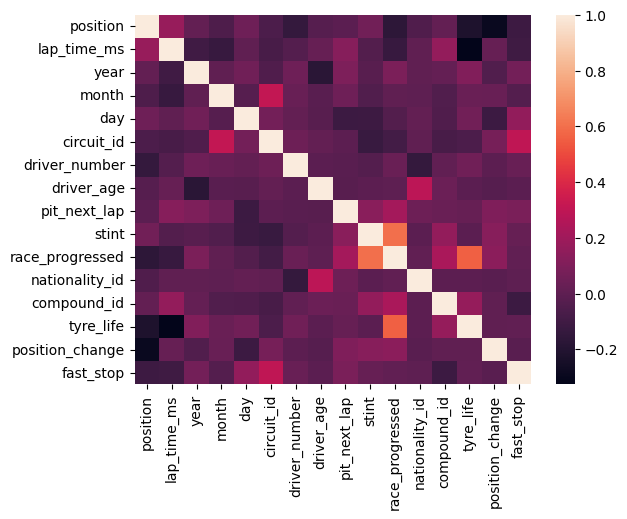

In [ ]:
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns)

<Axes: xlabel='fast_stop', ylabel='race_progressed'>

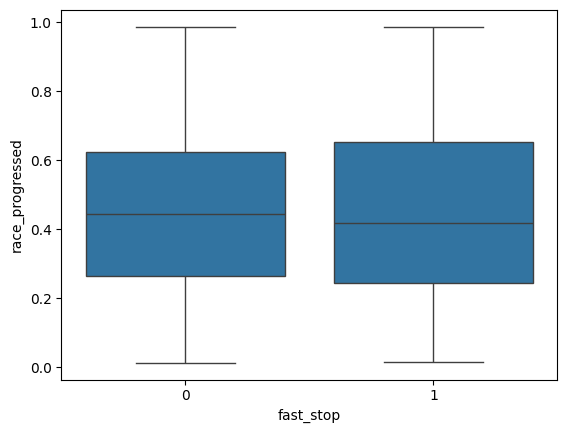

In [ ]:
sns.boxplot(y="race_progressed", x="fast_stop", data=raw_df_train)

In [ ]:
x_train = raw_df_train.drop('fast_stop', axis=1)
x_test = raw_df_test.drop('fast_stop', axis=1)

y_train = raw_df_train['fast_stop']
y_test = raw_df_test['fast_stop']

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2089, 15)
X_test shape: (523, 15)
y_train shape: (2089,)
y_test shape: (523,)


In [ ]:
x_train.head()

,position,lap_time_ms,year,month,day,circuit_id,driver_number,driver_age,pit_next_lap,stint,race_progressed,nationality_id,compound_id,tyre_life,position_change
1914,19,104961,2023,9,24,22,2,25,0,2,0.094340,1,2.0,5.0,0
1771,18,92185,2022,9,11,14,11,36,0,1,0.132075,15,2.0,7.0,-5
54,14,96858,2024,3,24,1,44,41,0,1,0.120690,5,1.0,7.0,-5
3006,17,126376,2024,11,3,18,24,27,0,2,0.394366,7,4.0,1.0,0
2597,16,148383,2025,4,20,77,61,23,0,1,0.020000,3,2.0,1.0,0


Train the model

In [ ]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,

Scale the data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(x_train)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
print(x_train['lap_time_ms'].mean())
print(x_train_scaled['lap_time_ms'].mean())
print(x_train['lap_time_ms'].std())
print(x_train_scaled['lap_time_ms'].std())

102913.02010531355
-3.7584955625414587e-16
16431.04181913148
1.0002394349369876


In [ ]:
model_scaled = LogisticRegression()
model_scaled.fit(x_train_scaled, y_train)
y_pred_scaled_model = model_scaled.predict(x_test_scaled)

Assessing Model

In [ ]:
accuracy = met.accuracy_score(y_test, y_pred)
balanced_accuracy = met.balanced_accuracy_score(y_test, y_pred)
f1 = met.f1_score(y_test, y_pred)

print("Accuracy stats for the unscaled data model:")
print("Accuracy:", np.round(accuracy*100.0,1))
print("Balanced Accuracy:", np.round(balanced_accuracy*100.0,2))

print("F1 Score:", np.round(f1*100.0,2))

Accuracy stats for the unscaled data model:
Accuracy: 65.6
Balanced Accuracy: 64.53
F1 Score: 58.72


In [ ]:
accuracy = met.accuracy_score(y_test, y_pred_scaled_model)
balanced_accuracy = met.balanced_accuracy_score(y_test, y_pred_scaled_model)
f1 = met.f1_score(y_test, y_pred_scaled_model)

print("Accuracy stats for the scaled data model:")
print("Accuracy:", np.round(accuracy*100.0,1))
print("Balanced Accuracy:", np.round(balanced_accuracy*100.0,2))

print("F1-score: ", np.round(f1*100.0,2))

Accuracy stats for the scaled data model:
Accuracy: 66.5
Balanced Accuracy: 65.74
F1-score:  60.85


Confusion Matrix

In [ ]:
cm = met.confusion_matrix(y_test, y_pred)
print(cm)

[[215  76]
 [104 128]]


In [ ]:
cm = met.confusion_matrix(y_test, y_pred_scaled_model)
print(cm)

[[212  79]
 [ 96 136]]


In [ ]:
def visualize_classification(y_test, y_pred):
  """
  Visualizes the classification performance by displaying a classification report
  and a confusion matrix heatmap.
  """
  cr = classification_report(y_test, y_pred)
  print("Classification Report:")
  print(cr)

  cf_metrix = confusion_matrix(y_test, y_pred.round())

  plt.figure(figsize=(10,7))
  sns.heatmap(cf_metrix/np.sum(cf_metrix), annot=True, fmt='.2%', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       291
           1       0.63      0.59      0.61       232

    accuracy                           0.67       523
   macro avg       0.66      0.66      0.66       523
weighted avg       0.66      0.67      0.66       523



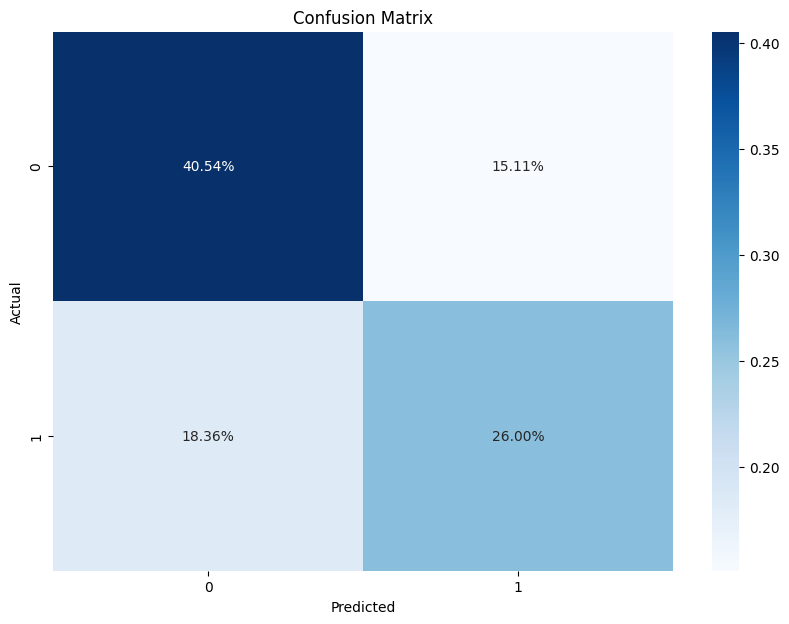

In [ ]:
visualize_classification(y_test, y_pred_scaled_model)

Enhanced matrix with ROC curve

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def plot_roc_cm(y_true, y_pred, model, name):
  fpr,tpr, thresholds = roc_curve(y_true, y_pred)
  roc_auc = auc(fpr, tpr)

  y_pred_binary = (y_pred > 0.5).astype(int)
  mat = confusion_matrix(y_true, y_pred_binary)
  cr = classification_report(y_true, y_pred_binary)
  print(cr)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
  ax1.plot(fpr, tpr, label='ROC curve (area = {:.2f})'. format(roc_auc))
  ax1.plot([0,1], [0,1], 'k--')
  ax1.set_xlabel('False Positive Rate')
  ax1.set_ylabel('True Positive Rate')
  ax1.set_title('ROC Curve of {}'.format(name))
  ax1.legend(loc='lower right')

  names = ["True Negative", "False Positive", "False Negative", "True Positive"]
  counts = ["{0:0.0f}".format(value) for value in mat.flatten()]
  percents = ["{0:.2%}".format(value) for value in mat.flatten()/np.sum(mat)]
  labels = ["{}\n{}\n{}".format(a, b, c) for a, b, c in zip(names, counts, percents)]
  labels = np.asarray(labels).reshape(2,2)
  sns.heatmap(mat, annot=labels, fmt="", cmap="Blues", ax=ax2)
  ax2.set(xlabel="Predicted", ylabel="Actual",
      title='Confusion Matrix of {}'.format(name))

  plt.tight_layout()
  plt.show()

              precision    recall  f1-score   support

           0       0.69      0.73      0.71       291
           1       0.63      0.59      0.61       232

    accuracy                           0.67       523
   macro avg       0.66      0.66      0.66       523
weighted avg       0.66      0.67      0.66       523



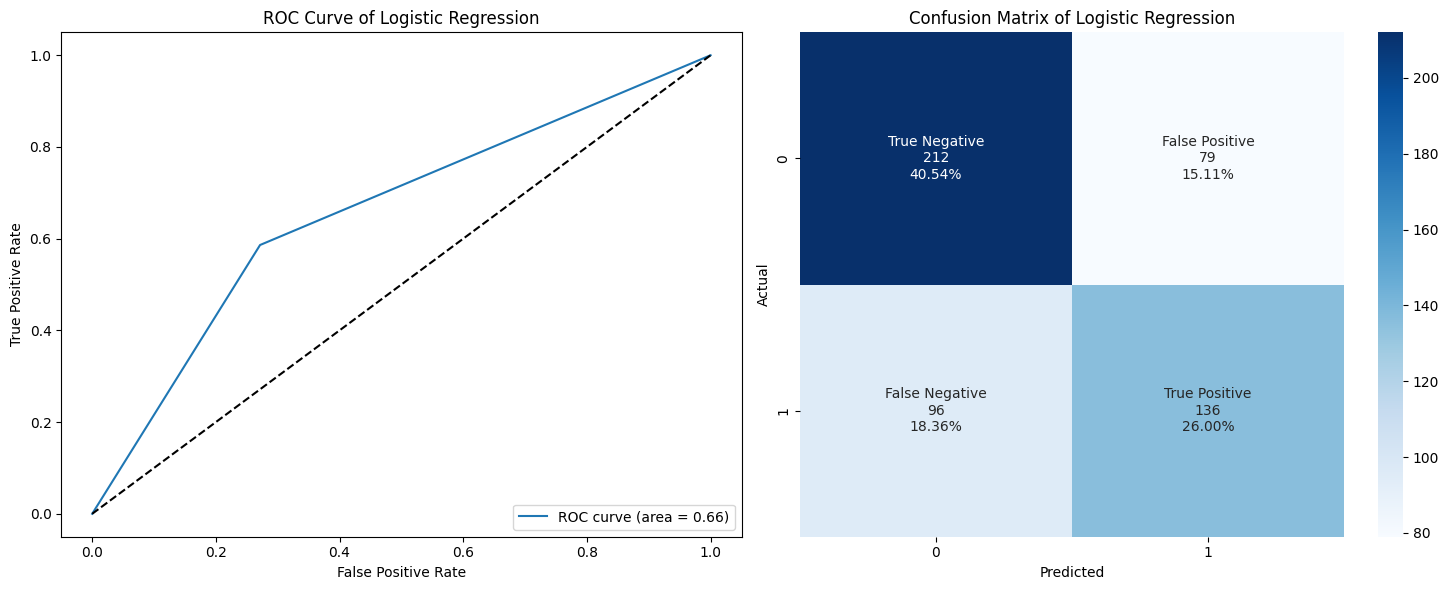

In [ ]:
plot_roc_cm(y_test, y_pred_scaled_model, model_scaled, 'Logistic Regression')

Interpreting the ML Model

In [ ]:
coeff_df = pd.DataFrame(zip(x_train.columns, model_scaled.coef_[0]))
coeff_df.columns = ["feature","coefficient"]
coeff_df['exp'] = np.exp(coeff_df['coefficient'])
coeff_df

,feature,coefficient,exp
0,position,-0.317146,0.728224
1,lap_time_ms,-0.169168,0.844367
2,year,0.150682,1.162626
3,month,-0.365262,0.694015
4,day,0.359985,1.433307
5,circuit_id,0.772876,2.165986
6,driver_number,-0.002956,0.997049
7,driver_age,0.016770,1.016911
8,pit_next_lap,0.284635,1.329277
9,stint,0.332224,1.394065


Plotting coefficients

Text(0.5, 0, 'Importance')

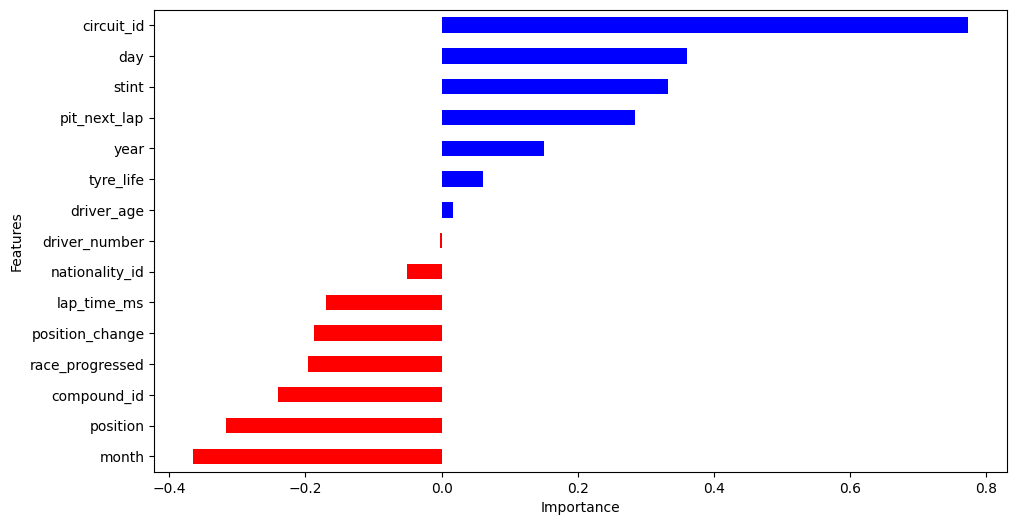

In [ ]:
coeff = list(model_scaled.coef_[0])
labels = list(x_train.columns)
features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)
features.importance.plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance')

Text(0.5, 0, 'Exponential of Coefficient')

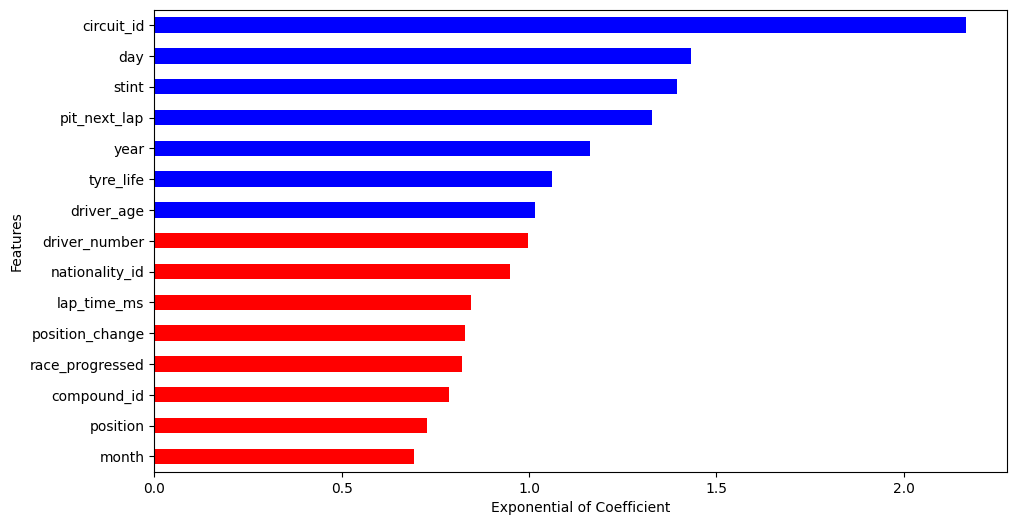

In [ ]:
coeff = list(model_scaled.coef_[0])
labels = list(x_train.columns)
features = pd.DataFrame()
features['Features'] = labels
features['coefficient'] = coeff
features['exponential'] = np.exp(features['coefficient']) # Calculate exponential
features.sort_values(by=['coefficient'], ascending=True, inplace=True) # Sort by coefficient to maintain original order
features['positive'] = features['coefficient'] > 0 # Keep coloring based on original coefficient sign
features.set_index('Features', inplace=True)
features['exponential'].plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'})) # Plot exponential
plt.xlabel('Exponential of Coefficient') # Update xlabel